## Import the dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load and inspect the dataset

In [2]:
cc_df = pd.read_csv('../data/raw/creditcard.csv')

In [3]:
print(cc_df.shape)
print(cc_df.head())
print(cc_df.info())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

# 2. Data cleaning

### 2.1. Missing value checks

In [4]:
print(cc_df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### 2.2. Duplicates and Data Types

In [5]:
print(cc_df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [6]:
# Duplicates
print("Duplicated rows: ", cc_df.duplicated().sum())

Duplicated rows:  1081


In [7]:
cc_df = cc_df.drop_duplicates()
print(cc_df.info)

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  

# 3. Exploratory Data Analysis (EDA)

## 3.1 Univariate Analysis

In [8]:
print(cc_df['Amount'].describe())

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64
The median is:  22.0


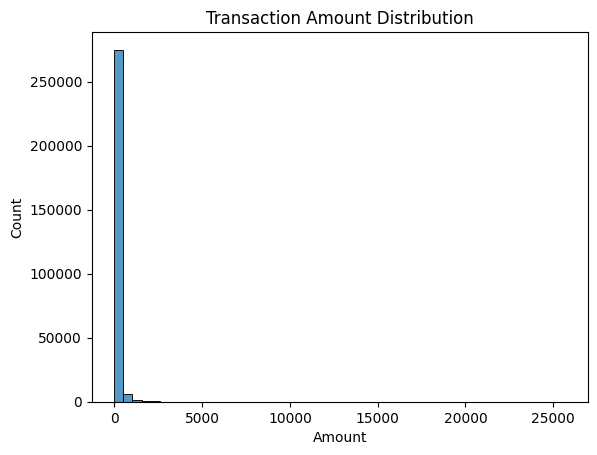

In [9]:
print(cc_df['Amount'].describe())
print("The median is: " , cc_df['Amount'].median())
sns.histplot(cc_df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.show()

Since there seems like to be an outlier in this dataset I want to draw a box plot.

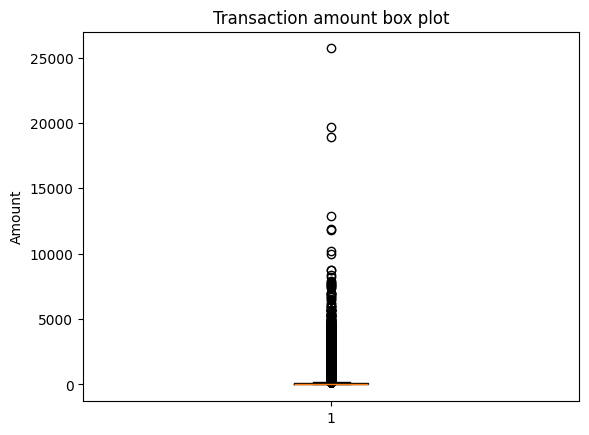

In [10]:
# I have to do a box plot analysis to look more in to the disperssion of the Amount column
plt.boxplot(cc_df['Amount'])
plt.title("Transaction amount box plot")
plt.ylabel("Amount")
plt.show()

This is exactly the kind of distribution where a plain StandardScaler can be misleading — a few extreme values in the tail can dominate the mean/std calculation, distorting the scale for the bulk of "normal" transactions. This is a strong candidate for a log transform (np.log1p(Amount)) before scaling, which compresses the tail and makes the bulk of the distribution easier for models to learn from.

## 3.2 Bivariate Analysis

In [11]:
print(cc_df['Amount'].value_counts())
print(cc_df['Amount'].value_counts(normalize=True) * 100)

Amount
1.00      13566
1.98       6044
0.89       4871
9.99       4738
15.00      3280
          ...  
301.34        1
614.00        1
279.79        1
615.52        1
180.93        1
Name: count, Length: 32767, dtype: int64
Amount
1.00      4.781374
1.98      2.130224
0.89      1.716797
9.99      1.669921
15.00     1.156045
            ...   
301.34    0.000352
614.00    0.000352
279.79    0.000352
615.52    0.000352
180.93    0.000352
Name: proportion, Length: 32767, dtype: float64


In [12]:
# Amount by Class
print(cc_df.groupby('Class')['Amount'].mean())
print(cc_df.groupby('Class')['Amount'].median())

Class
0     88.413575
1    123.871860
Name: Amount, dtype: float64
Class
0    22.00
1     9.82
Name: Amount, dtype: float64


<Axes: xlabel='Class', ylabel='Amount'>

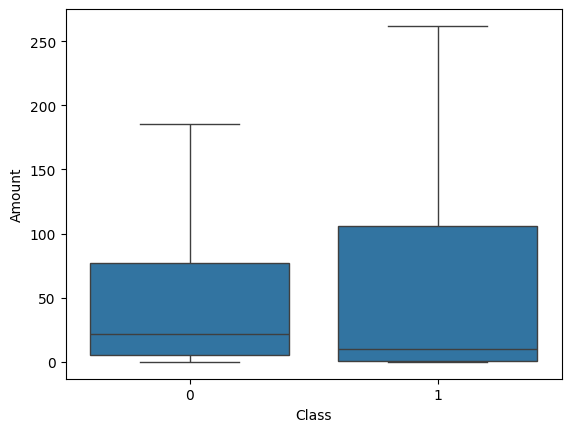

In [13]:
sns.boxplot(data=cc_df, x='Class', y='Amount', showfliers=False)

### Findings of Bivariate Analysis
 - Mean - Fraud >  Legitmate
- Median - Fraud < Legitmate

Fraudulent transaction amounts may have a highly skewed distribution, where most fraudulent transactions are relatively small but a small number of extremely large transactions substantially increase the mean.


In [14]:
print("Columns in cc_df:")
print(cc_df.columns.tolist())
print()
print("Shape:", cc_df.shape)

Columns in cc_df:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Shape: (283726, 31)
